# Resultados consolidados (Q1-Q6) - análise de dados

Analise unificada de todos os resultados em `results/`. Cada questão tem sua leitura, e
ao final ha uma síntese transversal (escala, custo x qualidade, mapa modelo x questão).

Convenções:
- Juiz: LLM fixo Qwen3-8B, escala 0-5 (maior melhor), comparável entre modelos.
- Perplexidade (PPL) e entropia cruzada (CE): menor melhor. PPL so e comparável dentro
  da mesma família de tokenizer (GPT-2 em inglês não se compara a Qwen/Gemma).
- Limite de hardware: 2x L4 (22 GB). 4B/8B full fine-tuning e o 31b RAG limpo ficam fora
  por memória, não por qualidade.

In [1]:
import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import PercentFormatter

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
    HAS_SNS = True
except Exception:
    HAS_SNS = False

try:
    from adjustText import adjust_text
    HAS_ADJUST = True
except Exception:
    HAS_ADJUST = False

RESULTS = "results" if os.path.isdir("results") else "../results"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.autolayout": False,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.grid": True,
    "grid.alpha": 0.3, "font.size": 9.5,
})

# qualitative palette by role (high contrast between depois/noft is intentional)
C = {"base": "#9e9e9e", "antes": "#9e9e9e", "depois": "#1f77b4", "noft": "#ff7f0e",
     "instruct": "#d62728", "sft": "#2ca02c", "lora": "#ff7f0e", "distill": "#9467bd",
     "rag": "#17becf", "good": "#2ca02c", "bad": "#d62728", "neutral": "#7f7f7f"}
# legendas em português para as condições do Q1
COND_PT = {"antes": "base (antes)", "depois": "base treinado (depois)", "noft": "instruct (sem treino)"}

def cols(keys, default="#1f77b4"):
    """Color list for a set of column keys, never None (pandas rejects None)."""
    return [C.get(k, default) for k in keys]

def text_on(rgba):
    """Black or white text for readability over a given cell color (luminance)."""
    r, g, b = mcolors.to_rgb(rgba)[:3]
    return "black" if (0.299 * r + 0.587 * g + 0.114 * b) > 0.55 else "white"

def annot_heat(ax, M, im, fmt="{:.2f}"):
    """Annotate a heatmap with per-cell contrasting bold text."""
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center",
                        fontsize=8, fontweight="bold", color=text_on(im.cmap(im.norm(v))))

def load(name):
    p = os.path.join(RESULTS, name)
    return pd.read_csv(p) if os.path.exists(p) else None

def skip(name):
    print(f"[pulado] {name} ainda não existe")

def params_to_m(s):
    """'0.6B'/'124M'/'1.0B' -> millions (float)."""
    if not isinstance(s, str):
        return np.nan
    m = re.match(r"([\d.]+)\s*([BM])", s.strip(), re.I)
    if not m:
        return np.nan
    v = float(m.group(1))
    return v * 1000 if m.group(2).upper() == "B" else v

def bar_labels(ax, fmt="{:.2f}", fontsize=8):
    for c in ax.containers:
        ax.bar_label(c, fmt=fmt, fontsize=fontsize, padding=2)

def load_rag_scores(fname, modes=("baseline", "standard", "agentic_graph")):
    """Per-question RAG score columns from a compare/student/engine CSV."""
    df = load(fname)
    if df is None:
        return None
    cols = {m: f"score_{m}" for m in modes if f"score_{m}" in df.columns}
    out = df[[c for c in ["idx", "type"] if c in df.columns] + list(cols.values())].copy()
    out = out.rename(columns={v: k for k, v in cols.items()})
    return out

print("results dir:", RESULTS, "| CSVs:", len(glob.glob(os.path.join(RESULTS, "*.csv"))))

results dir: ../results | CSVs: 57


## 1. Panorama - leaderboard do pós-treino (docentes, recall n=150)

Comparação justa entre SFT pleno e LoRA no mesmo conjunto de recall e mesmo juiz. Cada
barra e um (modelo, método, ponto de partida). Distillation (Q4) usa outro conjunto
(n=100) e aparece na seção Q4.

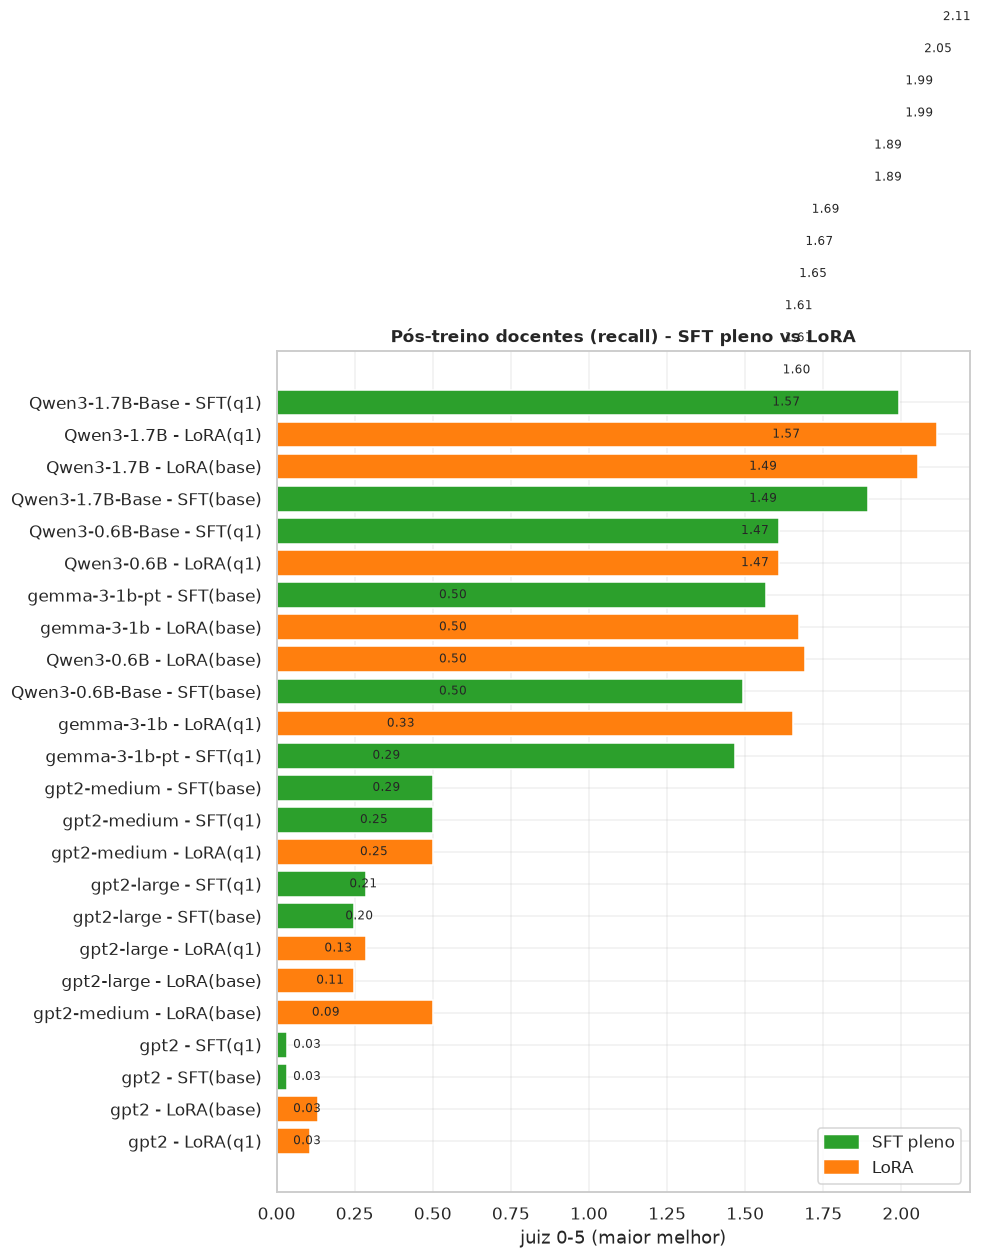

In [2]:
sft = load("q2_sft.csv"); lora = load("q3_lora.csv")
rows = []
if sft is not None:
    s = sft[(sft.eval_set == "recall") & (sft.condition == "sft")].copy()
    s["label"] = s["model"] + " - SFT(" + s["start"] + ")"
    s["method"] = "SFT pleno"
    rows.append(s[["label", "params", "mean_judge", "method"]])
if lora is not None:
    l = lora[lora.eval_set == "recall"].copy()
    l["label"] = l["model"] + " - LoRA(" + l["start"] + ")"
    l["method"] = "LoRA"
    rows.append(l[["label", "params", "mean_judge", "method"]])

if not rows:
    skip("q2_sft.csv / q3_lora.csv")
else:
    lb = pd.concat(rows, ignore_index=True).dropna(subset=["mean_judge"])
    lb = lb.sort_values("mean_judge")
    colors = [C["sft"] if m == "SFT pleno" else C["lora"] for m in lb["method"]]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.34 * len(lb))))
    ax.barh(lb["label"], lb["mean_judge"], color=colors)
    ax.set_xlabel("juiz 0-5 (maior melhor)")
    ax.set_title("Pós-treino docentes (recall) - SFT pleno vs LoRA")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=C["sft"], label="SFT pleno"),
                       Patch(color=C["lora"], label="LoRA")], loc="lower right")
    for y, v in enumerate(lb["mean_judge"]):
        ax.text(v + 0.02, y, f"{v:.2f}", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

## 2. Q1 - Pré-treino contínuo

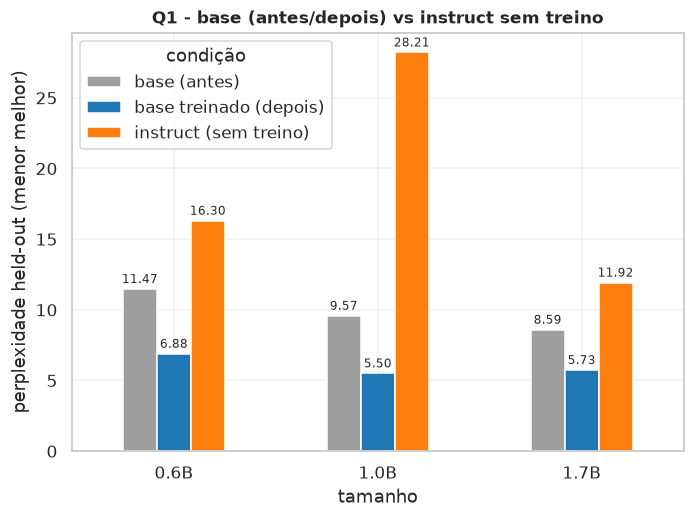

In [3]:
# base antes/depois vs instruct sem treino (Qwen/Gemma; held-out, PPL menor melhor)
df = load("q1_base_vs_instruct.csv")
if df is None: skip("q1_base_vs_instruct.csv")
else:
    d = df[df.eval_set == "heldout"]
    piv = d.pivot_table(index="params", columns="condition", values="ppl", aggfunc="first")
    piv = piv.reindex([x for x in ["0.6B", "1.0B", "1.7B"] if x in piv.index])
    order = [c for c in ["antes", "depois", "noft"] if c in piv.columns]
    piv = piv[order]
    ax = piv.plot(kind="bar", color=cols(order))
    ax.set_ylabel("perplexidade held-out (menor melhor)"); ax.set_xlabel("tamanho")
    ax.set_title("Q1 - base (antes/depois) vs instruct sem treino")
    ax.legend([COND_PT.get(c, c) for c in order], title="condição")
    plt.xticks(rotation=0); bar_labels(ax); plt.tight_layout(); plt.show()

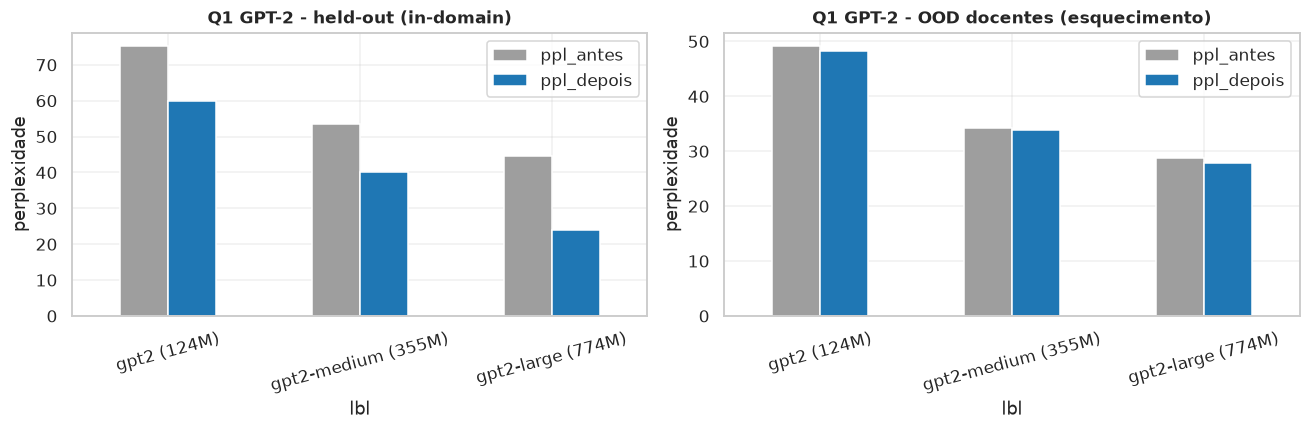

In [4]:
# GPT-2 (escala propria): delta antes/depois held-out e OOD (esquecimento)
g = load("q1_gpt2.csv")
if g is None: skip("q1_gpt2.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for k, (s, title) in enumerate([("heldout", "held-out (in-domain)"),
                                    ("ood_docentes", "OOD docentes (esquecimento)")]):
        dd = g[g.eval_set == s].copy()
        dd["lbl"] = dd["model"] + " (" + dd["params"] + ")"
        dd.set_index("lbl")[["ppl_antes", "ppl_depois"]].plot(
            kind="bar", ax=ax[k], color=[C["base"], C["depois"]])
        ax[k].set_title(f"Q1 GPT-2 - {title}"); ax[k].set_ylabel("perplexidade")
        ax[k].tick_params(axis="x", rotation=15)
    plt.tight_layout(); plt.show()

### Q1 - Qwen/Gemma: held-out vs OOD docentes (antes/depois)

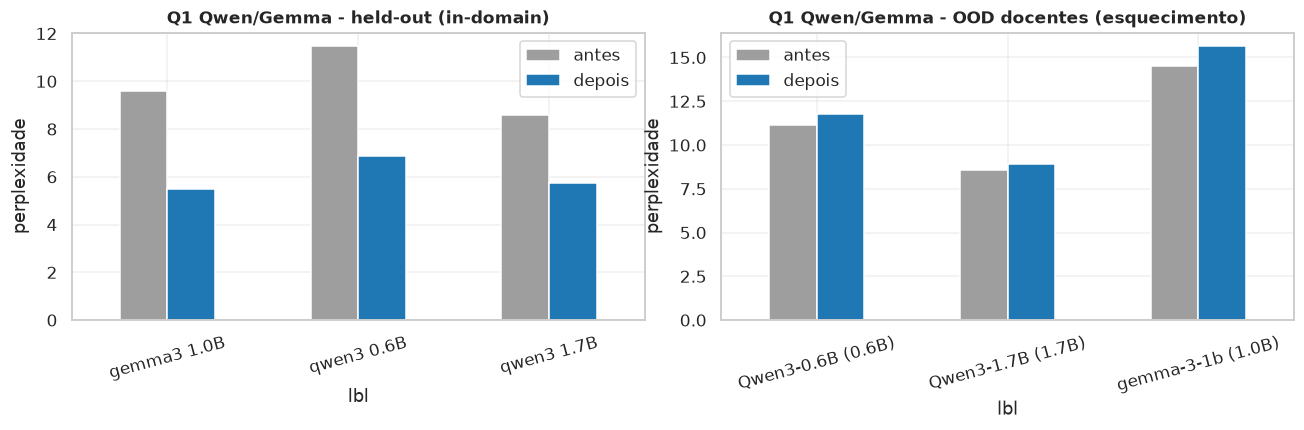

In [5]:
# mesmo recorte do GPT-2 acima, para Qwen/Gemma: held-out in-domain e OOD docentes
bi = load("q1_base_vs_instruct.csv"); fg = load("q1_forgetting.csv")
if bi is None or fg is None: skip("q1_base_vs_instruct.csv / q1_forgetting.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    h = bi[(bi.eval_set == "heldout") & (bi.family.isin(["qwen3", "gemma3"]))
           & (bi.condition.isin(["antes", "depois"]))].copy()
    h["lbl"] = h["family"] + " " + h["params"]
    ph = h.pivot_table(index="lbl", columns="condition", values="ppl", aggfunc="first")[["antes", "depois"]]
    ph.plot(kind="bar", ax=ax[0], color=[C["antes"], C["depois"]])
    ax[0].set_title("Q1 Qwen/Gemma - held-out (in-domain)"); ax[0].set_ylabel("perplexidade")
    ax[0].legend(["antes", "depois"]); ax[0].tick_params(axis="x", rotation=15)
    o = fg[(fg.eval_set == "ood_docentes") & (~fg.model.str.startswith("gpt2"))].copy()
    o["lbl"] = o["model"] + " (" + o["params"] + ")"
    o.set_index("lbl")[["ppl_antes", "ppl_depois"]].plot(kind="bar", ax=ax[1], color=[C["antes"], C["depois"]])
    ax[1].set_title("Q1 Qwen/Gemma - OOD docentes (esquecimento)"); ax[1].set_ylabel("perplexidade")
    ax[1].legend(["antes", "depois"]); ax[1].tick_params(axis="x", rotation=15)
    plt.tight_layout(); plt.show()

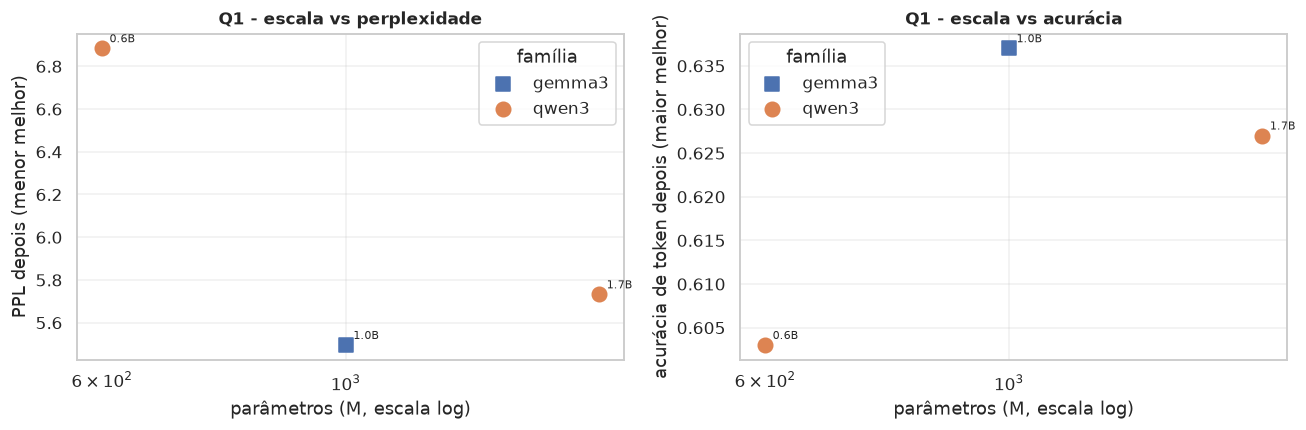

In [6]:
# escala: PPL depois e token-acc vs tamanho (familias com antes/depois completo)
df = load("q1_base_vs_instruct.csv")
if df is None: skip("q1_base_vs_instruct.csv")
else:
    d = df[(df.eval_set == "heldout") & (df.condition == "depois")].copy()
    d["m"] = d["params"].map(params_to_m)
    d = d.dropna(subset=["m"]).sort_values("m")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    markers = {"qwen3": "o", "gemma3": "s", "gpt2": "^"}
    for fam, grp in d.groupby("family"):
        mk = markers.get(fam, "D")
        ax[0].scatter(grp["m"], grp["ppl"], s=90, marker=mk, label=fam, zorder=3)
        ax[1].scatter(grp["m"], grp["tokacc"], s=90, marker=mk, label=fam, zorder=3)
        for _, r in grp.iterrows():
            ax[0].annotate(r["params"], (r["m"], r["ppl"]), fontsize=7,
                           xytext=(5, 4), textcoords="offset points")
            ax[1].annotate(r["params"], (r["m"], r["tokacc"]), fontsize=7,
                           xytext=(5, 4), textcoords="offset points")
    ax[0].set_ylabel("PPL depois (menor melhor)"); ax[0].set_title("Q1 - escala vs perplexidade")
    ax[1].set_ylabel("acurácia de token depois (maior melhor)"); ax[1].set_title("Q1 - escala vs acurácia")
    for a in ax:
        a.set_xscale("log"); a.set_xlabel("parâmetros (M, escala log)"); a.legend(title="família")
    plt.tight_layout(); plt.show()

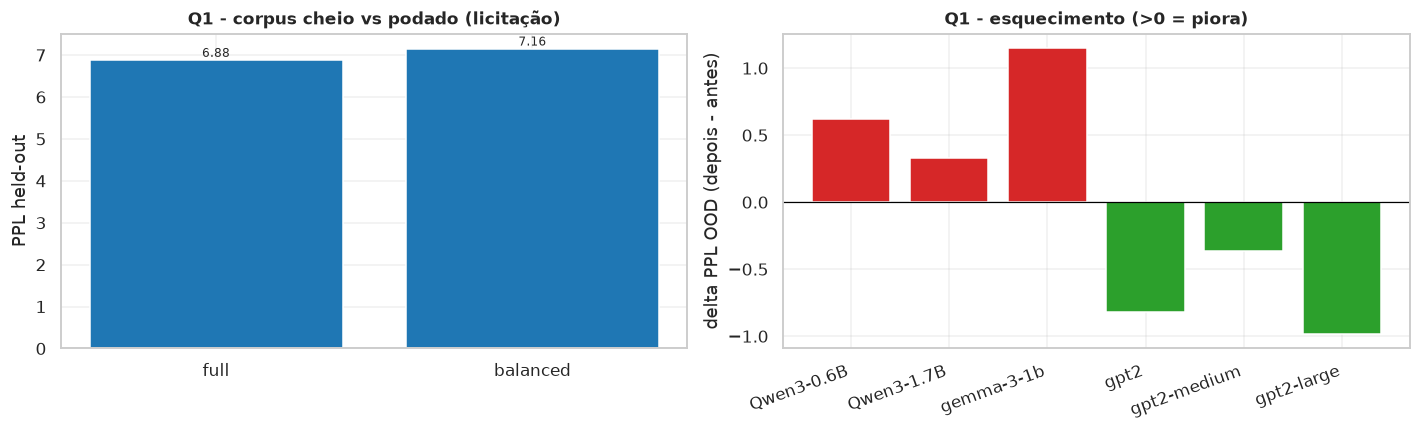

In [7]:
# ablação licitação (PPL) + esquecimento OOD (delta PPL)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
lic = load("q1_balanceamento_licitacao.csv")
if lic is not None:
    d = lic[(lic.eval_set == "heldout_orig") & (lic.condition == "depois")].copy()
    piv = d.set_index("train_corpus")["ppl"].sort_values()
    ax[0].bar(piv.index, piv.values, color=C["depois"])
    ax[0].set_ylabel("PPL held-out"); ax[0].set_title("Q1 - corpus cheio vs podado (licitação)")
    ax[0].tick_params(axis="x", rotation=0)
    for i, v in enumerate(piv.values): ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
else:
    ax[0].set_title("q1_balanceamento_licitacao.csv ausente")
fg = load("q1_forgetting.csv")
if fg is not None:
    ood = fg[fg.eval_set == "ood_docentes"]
    colors = [C["bad"] if v > 0 else C["good"] for v in ood["delta_ppl"]]
    ax[1].bar(ood["model"], ood["delta_ppl"], color=colors)
    ax[1].axhline(0, color="black", lw=0.8)
    ax[1].set_ylabel("delta PPL OOD (depois - antes)")
    ax[1].set_title("Q1 - esquecimento (>0 = piora)")
    plt.setp(ax[1].get_xticklabels(), rotation=20, ha="right")
else:
    ax[1].set_title("q1_forgetting.csv ausente")
plt.tight_layout(); plt.show()

## 3. Q2 (SFT) e Q3 (LoRA)

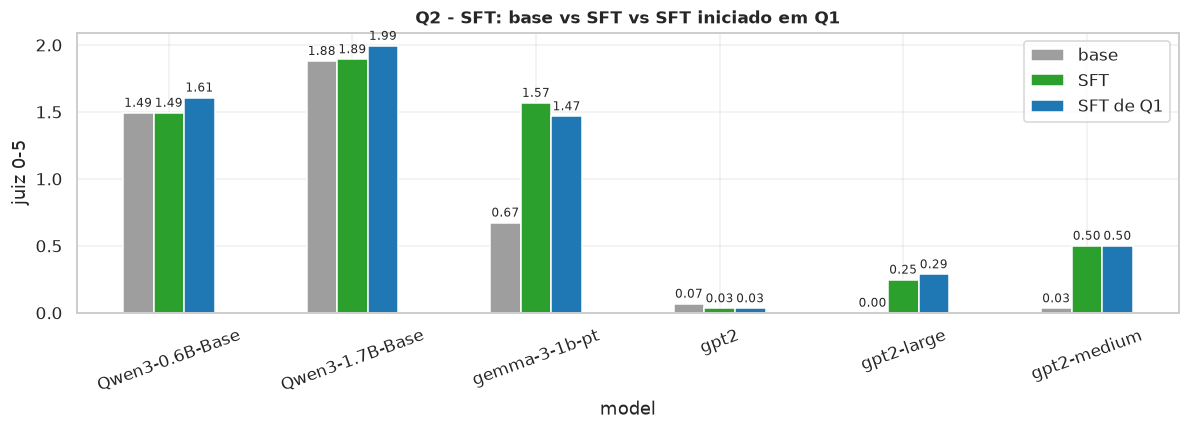

In [8]:
# Q2 SFT: base vs SFT vs SFT-de-Q1 (juiz, recall)
df = load("q2_sft.csv")
if df is None: skip("q2_sft.csv")
else:
    d = df[df.eval_set == "recall"].copy()
    base = d[d.condition == "antes"].groupby("model")["mean_judge"].first()
    sft0 = d[(d.condition == "sft") & (d.start == "base")].groupby("model")["mean_judge"].first()
    sftq1 = d[(d.condition == "sft") & (d.start == "q1")].groupby("model")["mean_judge"].first()
    piv = pd.DataFrame({"base": base, "SFT": sft0, "SFT de Q1": sftq1}).dropna(how="all")
    piv = piv.loc[piv.index.intersection(["Qwen3-0.6B-Base", "Qwen3-1.7B-Base", "gemma-3-1b-pt",
                                          "gpt2", "gpt2-medium", "gpt2-large"])]
    ax = piv.plot(kind="bar", color=[C["base"], C["sft"], C["depois"]], figsize=(11, 4))
    ax.set_ylabel("juiz 0-5"); ax.set_title("Q2 - SFT: base vs SFT vs SFT iniciado em Q1")
    ax.tick_params(axis="x", rotation=20); bar_labels(ax); plt.tight_layout(); plt.show()

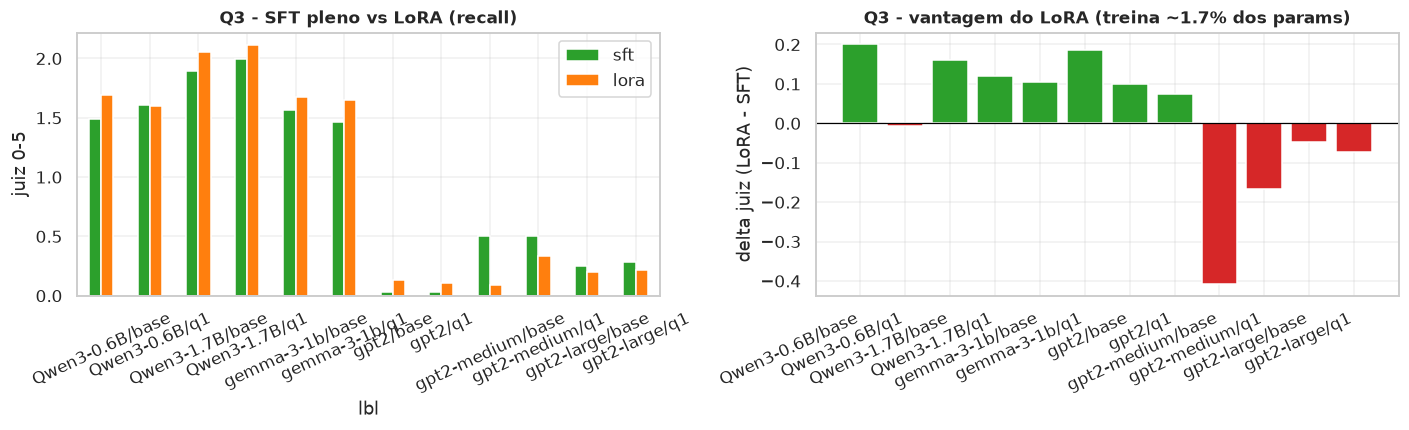

média delta (LoRA - SFT pleno): 0.02 | LoRA >= SFT em 7 de 12


In [9]:
# Q3 LoRA vs SFT pleno (juiz recall) + custo (LoRA treina fração dos params)
lora = load("q3_lora.csv"); sft = load("q2_sft.csv")
if lora is None or sft is None: skip("q3_lora.csv / q2_sft.csv")
else:
    l = lora[lora.eval_set == "recall"].copy()
    l["key"] = l["model"] + "/" + l["start"]
    lj = l.groupby("key")["mean_judge"].first()
    s = sft[(sft.eval_set == "recall") & (sft.condition == "sft")].copy()
    s["key"] = s["model"].str.replace("-Base", "", regex=False).str.lower().str.replace("qwen3-", "", regex=False)
    # build comparable pairs by (model,start) using readable labels from lora side
    pairs = l[["model", "start", "key"]].drop_duplicates()
    pairs["lora"] = pairs["key"].map(lj)
    # match SFT pleno by model+start
    sm = sft[(sft.eval_set == "recall") & (sft.condition == "sft")].copy()
    def sft_match(model, start):
        cand = sm[(sm["params"] == l[l.model == model]["params"].iloc[0]) & (sm["start"] == start)]
        return cand["mean_judge"].iloc[0] if len(cand) else np.nan
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    plot = pairs.dropna(subset=["lora"]).copy()
    plot["sft"] = [sft_match(m, st) for m, st in zip(plot["model"], plot["start"])]
    plot["lbl"] = plot["model"].str.replace("-Base", "", regex=False) + "/" + plot["start"]
    plot = plot.dropna(subset=["sft"]).set_index("lbl")[["sft", "lora"]]
    plot.plot(kind="bar", ax=ax[0], color=[C["sft"], C["lora"]])
    ax[0].set_ylabel("juiz 0-5"); ax[0].set_title("Q3 - SFT pleno vs LoRA (recall)")
    ax[0].tick_params(axis="x", rotation=25)
    delta = (plot["lora"] - plot["sft"])
    ax[1].bar(range(len(delta)), delta.values,
              color=[C["good"] if v >= 0 else C["bad"] for v in delta.values])
    ax[1].axhline(0, color="black", lw=0.8); ax[1].set_xticks(range(len(delta)))
    ax[1].set_xticklabels(delta.index, rotation=25, ha="right")
    ax[1].set_ylabel("delta juiz (LoRA - SFT)")
    ax[1].set_title("Q3 - vantagem do LoRA (treina ~1.7% dos params)")
    plt.tight_layout(); plt.show()
    print("média delta (LoRA - SFT pleno):", round(delta.mean(), 3),
          "| LoRA >= SFT em", int((delta >= 0).sum()), "de", len(delta))

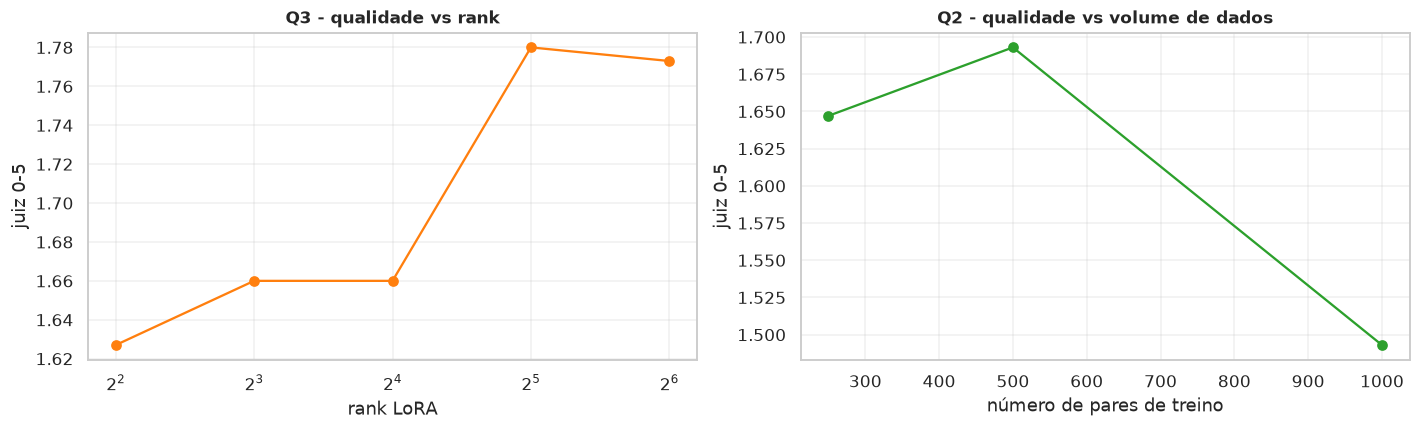

In [10]:
# Q3 varredura de rank + Q2 curva de dados
rk = load("q3_rank_sweep.csv"); dc = load("q2_data_curve.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
if rk is not None:
    rk = rk.copy(); rk["r"] = rk["model"].str.extract(r"r(\d+)").astype(float)
    rk = rk.dropna(subset=["r"]).sort_values("r")
    ax[0].plot(rk["r"], rk["mean_judge"], "o-", color=C["lora"])
    ax[0].set_xscale("log", base=2); ax[0].set_xlabel("rank LoRA")
    ax[0].set_ylabel("juiz 0-5"); ax[0].set_title("Q3 - qualidade vs rank")
else: ax[0].set_title("q3_rank_sweep.csv ausente")
if dc is not None:
    dc = dc.copy(); dc["n"] = dc["model"].str.extract(r"n(\d+)").astype(float)
    dc = dc.dropna(subset=["n"]).sort_values("n")
    ax[1].plot(dc["n"], dc["mean_judge"], "o-", color=C["sft"])
    ax[1].set_xlabel("número de pares de treino"); ax[1].set_ylabel("juiz 0-5")
    ax[1].set_title("Q2 - qualidade vs volume de dados")
else: ax[1].set_title("q2_data_curve.csv ausente")
plt.tight_layout(); plt.show()

## 4. Q4 - Destilação (teacher -> student)

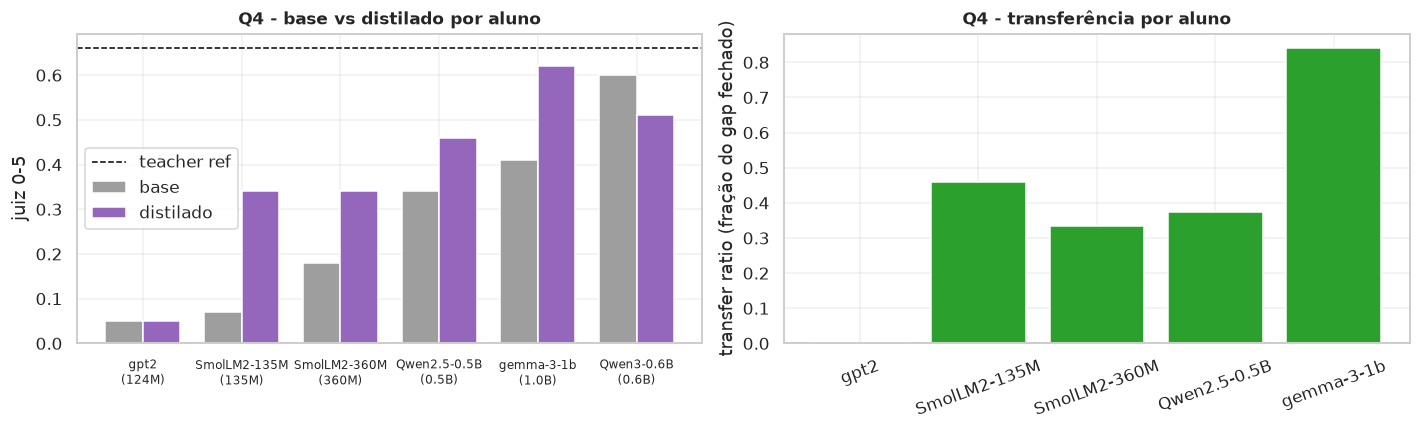

In [11]:
# base vs distill (juiz) + transfer ratio por aluno
df = load("q4_distill.csv")
if df is None: skip("q4_distill.csv")
else:
    d = df.copy().sort_values("base_judge")
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    idx = np.arange(len(d)); w = 0.38
    ax[0].bar(idx - w/2, d["base_judge"], w, label="base", color=C["base"])
    ax[0].bar(idx + w/2, d["distill_judge"], w, label="distilado", color=C["distill"])
    ax[0].axhline(d["teacher_judge"].iloc[0], ls="--", c="black", lw=1, label="teacher ref")
    ax[0].set_xticks(idx); ax[0].set_xticklabels(d["student"] + "\n(" + d["params"] + ")", fontsize=8)
    ax[0].set_ylabel("juiz 0-5"); ax[0].set_title("Q4 - base vs distilado por aluno"); ax[0].legend()
    tr = d.dropna(subset=["transfer_ratio"]).copy()
    tr = tr[tr["transfer_ratio"].between(-0.01, 1.5)]  # esconde caso degenerado (>gap negativo)
    ax[1].bar(tr["student"], tr["transfer_ratio"],
              color=[C["good"] if v > 0 else C["bad"] for v in tr["transfer_ratio"]])
    ax[1].set_ylabel("transfer ratio (fração do gap fechado)")
    ax[1].set_title("Q4 - transferência por aluno"); ax[1].tick_params(axis="x", rotation=20)
    plt.tight_layout(); plt.show()

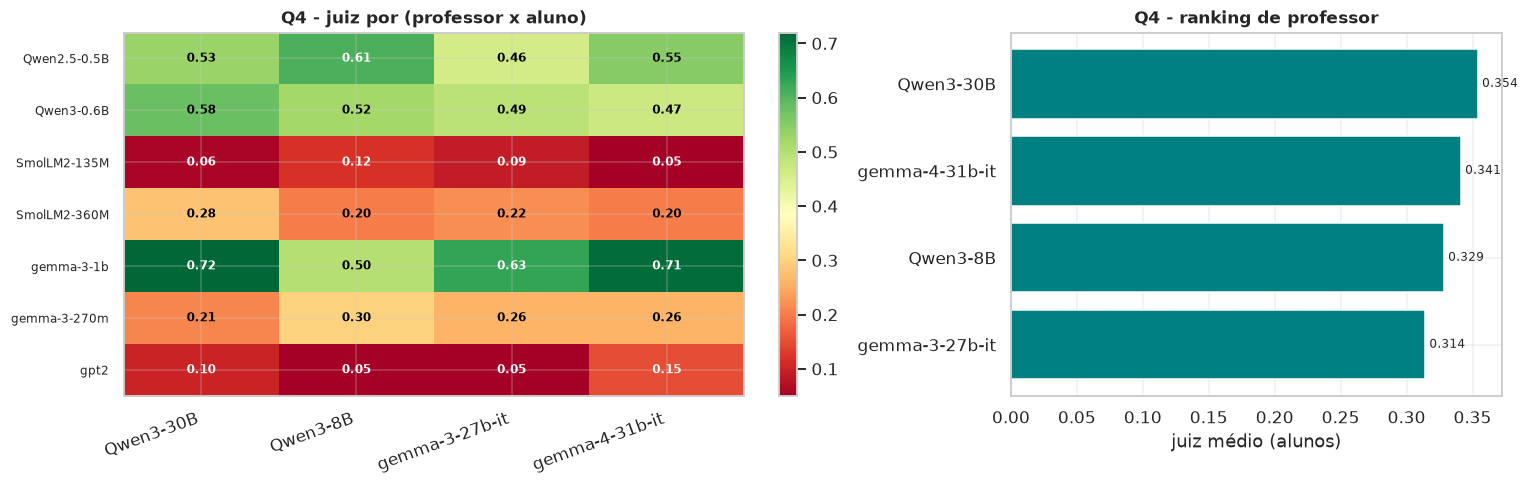

In [12]:
# teacher x student (heatmap) + ranking médio de professor
tc = load("q4_teacher_compare.csv")
if tc is None: skip("q4_teacher_compare.csv")
else:
    piv = tc.pivot_table(index="student", columns="teacher", values="mean_judge", aggfunc="first")
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})
    im = ax[0].imshow(piv.values, cmap="RdYlGn", aspect="auto")
    ax[0].set_xticks(range(len(piv.columns))); ax[0].set_xticklabels(piv.columns, rotation=20, ha="right")
    ax[0].set_yticks(range(len(piv.index))); ax[0].set_yticklabels(piv.index, fontsize=8)
    annot_heat(ax[0], piv, im)
    ax[0].set_title("Q4 - juiz por (professor x aluno)"); fig.colorbar(im, ax=ax[0], fraction=0.046)
    means = tc.groupby("teacher")["mean_judge"].mean().sort_values()
    ax[1].barh(means.index, means.values, color="teal")
    ax[1].set_xlabel("juiz médio (alunos)"); ax[1].set_title("Q4 - ranking de professor")
    for y, v in enumerate(means.values): ax[1].text(v + 0.003, y, f"{v:.3f}", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

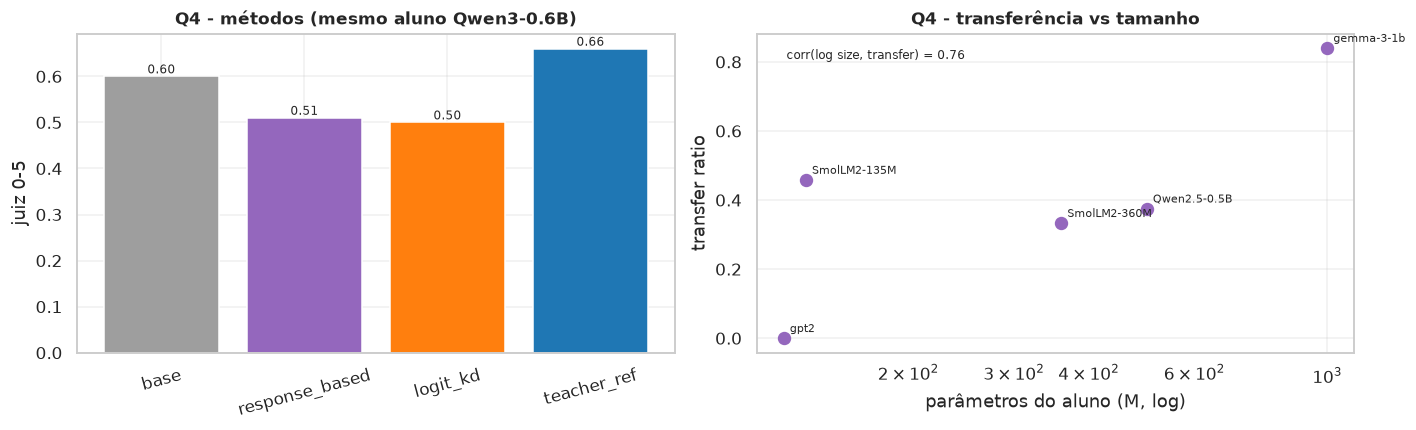

In [13]:
# métodos (response-based vs logit-KD) + transfer ratio vs tamanho do aluno
me = load("q4_methods.csv"); ds = load("q4_distill.csv")
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
if me is not None:
    m = me.set_index("method")["mean_judge"]
    ax[0].bar(m.index, m.values, color=[C["base"], C["distill"], C["lora"], C["depois"]][:len(m)])
    ax[0].set_ylabel("juiz 0-5"); ax[0].set_title("Q4 - métodos (mesmo aluno Qwen3-0.6B)")
    ax[0].tick_params(axis="x", rotation=15)
    for i, v in enumerate(m.values): ax[0].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
else: ax[0].set_title("q4_methods.csv ausente")
if ds is not None:
    d = ds.copy(); d["m"] = d["params"].map(params_to_m)
    d = d.dropna(subset=["m", "transfer_ratio"])
    d = d[d["transfer_ratio"].between(-0.01, 1.5)]
    ax[1].scatter(d["m"], d["transfer_ratio"], s=60, color=C["distill"])
    for _, r in d.iterrows():
        ax[1].annotate(r["student"], (r["m"], r["transfer_ratio"]), fontsize=7,
                       xytext=(4, 4), textcoords="offset points")
    ax[1].set_xscale("log"); ax[1].set_xlabel("parâmetros do aluno (M, log)")
    ax[1].set_ylabel("transfer ratio"); ax[1].set_title("Q4 - transferência vs tamanho")
    if len(d) > 2:
        c = np.corrcoef(np.log10(d["m"]), d["transfer_ratio"])[0, 1]
        ax[1].text(0.05, 0.92, f"corr(log size, transfer) = {c:.2f}", transform=ax[1].transAxes, fontsize=8)
else: ax[1].set_title("q4_distill.csv ausente")
plt.tight_layout(); plt.show()

## 5. Q5 - RAG (motores, modos, contribuição)

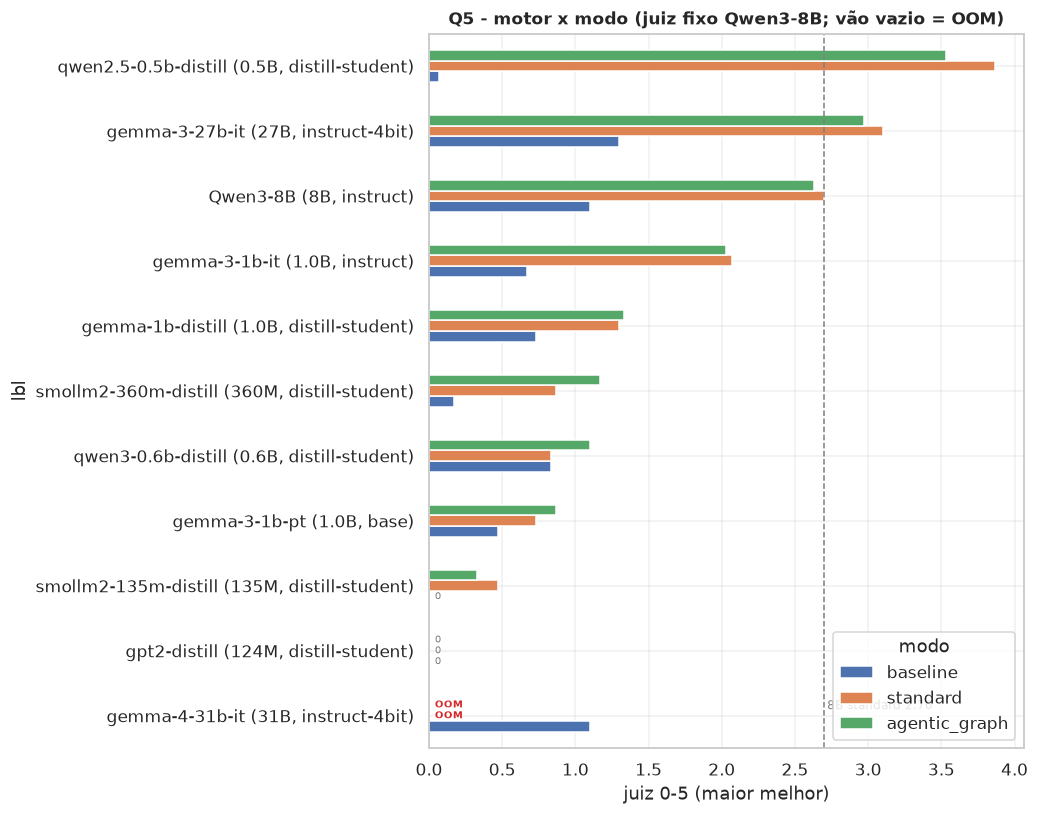

In [14]:
# leaderboard motor x modo (juiz fixo 8B)
e = load("q5_engines.csv")
if e is None: skip("q5_engines.csv")
else:
    e = e.copy(); e["lbl"] = e["engine"] + " (" + e["params"] + ", " + e["kind"] + ")"
    piv = e.pivot_table(index="lbl", columns="mode", values="judge", aggfunc="first")
    # baseline/standard/agentic_graph sao medidos em quase todos os motores; assim um vão
    # vazio nessas colunas indica falha real (OOM), não um modo não avaliado.
    modes = [m for m in ["baseline", "standard", "agentic_graph"] if m in piv.columns]
    piv = piv[modes].sort_values("standard", na_position="first")
    ax = piv.plot(kind="barh", figsize=(9.5, 7.5))
    ax.set_xlabel("juiz 0-5 (maior melhor)")
    ax.set_title("Q5 - motor x modo (juiz fixo Qwen3-8B; vão vazio = OOM)")
    ax.axvline(2.70, ls="--", c="gray", lw=1)
    ax.text(2.72, 0.1, "8B standard 2.70", color="gray", fontsize=8)
    # anota OOM (sem barra) e 0 (barra nula) no lugar onde a barra deveria estar
    for cont, mode in zip(ax.containers, piv.columns):
        for patch, val in zip(cont.patches, piv[mode].values):
            y = patch.get_y() + patch.get_height() / 2
            if pd.isna(val):
                ax.text(0.04, y, "OOM", va="center", ha="left", fontsize=6.5,
                        color=C["bad"], fontweight="bold")
            elif val == 0:
                ax.text(0.04, y, "0", va="center", ha="left", fontsize=6.5, color=C["neutral"])
    ax.legend(title="modo", loc="lower right")
    plt.tight_layout(); plt.show()

/tmp/ipykernel_739264/2992105357.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, showmeans=True, positions=positions,


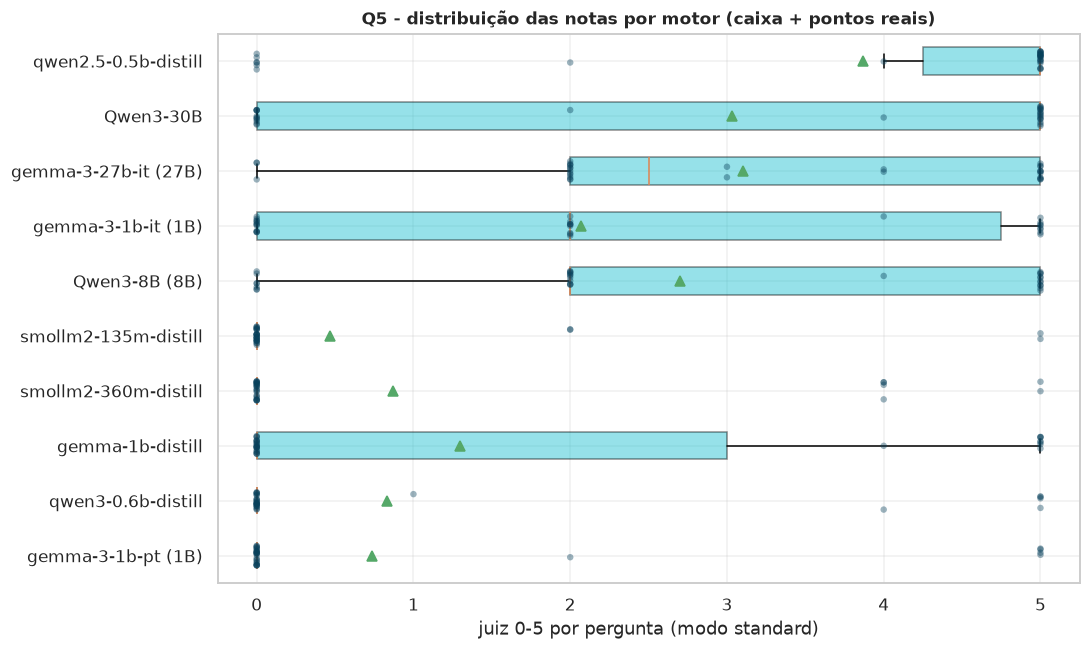

In [15]:
# distribuição por pergunta (modo standard) entre motores - boxplot
engine_files = {
    "Qwen3-8B (8B)": "benchmark_rag_compare_qwen8b.csv",
    "gemma-3-27b-it (27B)": "q5_engine_gemma-3-27b-it.csv",
    "Qwen3-30B": "q5_rag_30b.csv",
    "gemma-3-1b-it (1B)": "benchmark_rag_compare_gemma1b_it.csv",
    "gemma-3-1b-pt (1B)": "benchmark_rag_compare_gemma1b_pt.csv",
    "qwen2.5-0.5b-distill": "q5_student_qwen2.5-0.5b-distill.csv",
    "qwen3-0.6b-distill": "q5_student_qwen3-0.6b-distill.csv",
    "gemma-1b-distill": "q5_student_gemma-1b-distill.csv",
    "smollm2-360m-distill": "q5_student_smollm2-360m-distill.csv",
    "smollm2-135m-distill": "q5_student_smollm2-135m-distill.csv",
}
data, labels = [], []
for name, f in engine_files.items():
    r = load_rag_scores(f)
    if r is not None and "standard" in r.columns:
        s = r["standard"].dropna()
        if len(s):
            data.append(s.values); labels.append(name)
if not data:
    skip("arquivos por-pergunta do Q5")
else:
    order = np.argsort([np.median(d) for d in data])
    data = [data[i] for i in order]; labels = [labels[i] for i in order]
    fig, ax = plt.subplots(figsize=(10, 6))
    positions = np.arange(1, len(data) + 1)
    bp = ax.boxplot(data, vert=False, patch_artist=True, showmeans=True, positions=positions,
                    flierprops=dict(marker="", markersize=0))  # outliers viram pontos no strip
    for patch in bp["boxes"]: patch.set_facecolor(C["rag"]); patch.set_alpha(0.45)
    # sobrepoe os pontos reais (densidade) com jitter e baixa opacidade
    rng = np.random.default_rng(0)
    for pos, vals in zip(positions, data):
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))
        ax.scatter(vals, pos + jitter, s=18, color="#08415c", alpha=0.4, zorder=3, edgecolors="none")
    ax.set_yticks(positions); ax.set_yticklabels(labels)
    ax.set_xlabel("juiz 0-5 por pergunta (modo standard)")
    ax.set_title("Q5 - distribuição das notas por motor (caixa + pontos reais)")
    plt.tight_layout(); plt.show()

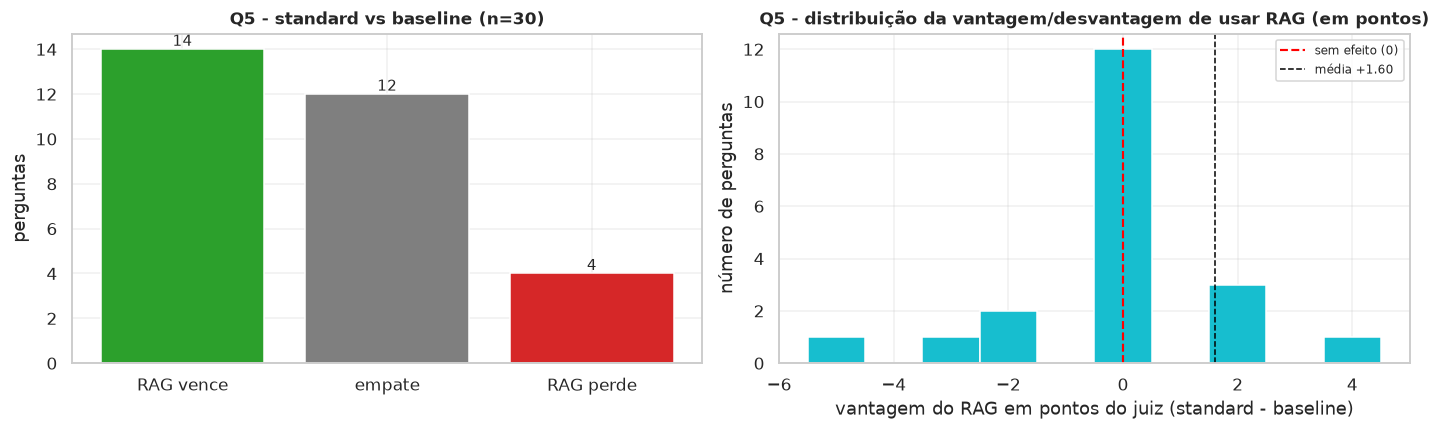

In [16]:
# contribuição do RAG vs baseline (8B, pareado por pergunta): win/tie/loss + histograma de delta
r = load_rag_scores("benchmark_rag_compare_qwen8b.csv", modes=("baseline", "standard", "agentic_graph"))
if r is None: skip("benchmark_rag_compare_qwen8b.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    rr = r.dropna(subset=["baseline", "standard"])
    delta = rr["standard"] - rr["baseline"]
    win = int((delta > 0).sum()); tie = int((delta == 0).sum()); loss = int((delta < 0).sum())
    ax[0].bar(["RAG vence", "empate", "RAG perde"], [win, tie, loss],
              color=[C["good"], C["neutral"], C["bad"]])
    ax[0].set_ylabel("perguntas"); ax[0].set_title(f"Q5 - standard vs baseline (n={len(rr)})")
    for i, v in enumerate([win, tie, loss]): ax[0].text(i, v, str(v), ha="center", va="bottom")
    ax[1].hist(delta, bins=np.arange(-5, 6) - 0.5, color=C["rag"], edgecolor="white")
    ax[1].axvline(0, color="red", ls="--", lw=1.4, label="sem efeito (0)")
    ax[1].axvline(delta.mean(), ls="--", c="black", lw=1, label=f"média {delta.mean():+.2f}")
    ax[1].set_xlabel("vantagem do RAG em pontos do juiz (standard - baseline)")
    ax[1].set_ylabel("número de perguntas")
    ax[1].set_title("Q5 - distribuição da vantagem/desvantagem de usar RAG (em pontos)")
    ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

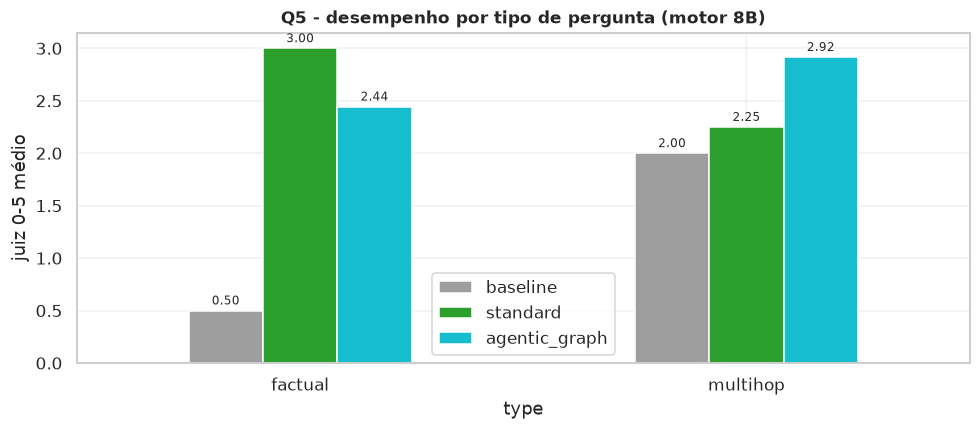

In [17]:
# ganho do RAG por tipo de pergunta (factual vs multihop), motor 8B
r = load_rag_scores("benchmark_rag_compare_qwen8b.csv", modes=("baseline", "standard", "agentic_graph"))
if r is None or "type" not in r.columns: skip("type em benchmark_rag_compare_qwen8b.csv")
else:
    g = r.groupby("type")[["baseline", "standard", "agentic_graph"]].mean()
    ax = g.plot(kind="bar", figsize=(9, 4), color=[C["base"], C["sft"], C["rag"]])
    ax.set_ylabel("juiz 0-5 médio"); ax.set_title("Q5 - desempenho por tipo de pergunta (motor 8B)")
    ax.tick_params(axis="x", rotation=0); bar_labels(ax); plt.tight_layout(); plt.show()

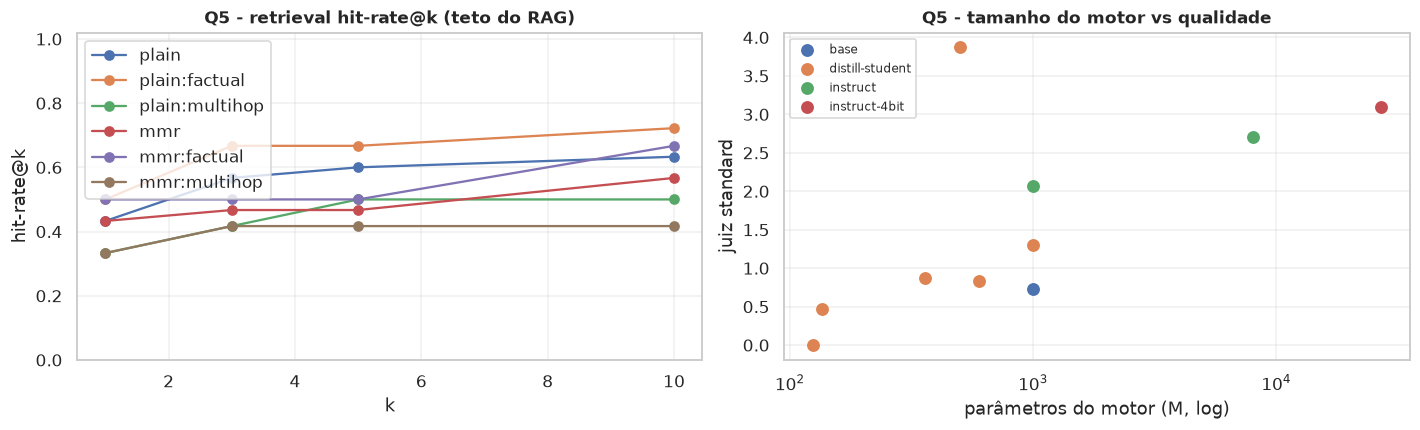

In [18]:
# retrieval hit-rate@k (teto) + tamanho do motor vs qualidade standard
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ret = load("q5_retrieval.csv")
if ret is not None:
    ks = [1, 3, 5, 10]
    for method in ret["method"].unique():
        row = ret[ret["method"] == method]
        if len(row): ax[0].plot(ks, [row[f"hit@{k}"].iloc[0] for k in ks], "o-", label=method)
    ax[0].set_xlabel("k"); ax[0].set_ylabel("hit-rate@k"); ax[0].set_ylim(0, 1.02)
    ax[0].set_title("Q5 - retrieval hit-rate@k (teto do RAG)"); ax[0].legend()
else: ax[0].set_title("q5_retrieval.csv ausente")
e = load("q5_engines.csv")
if e is not None:
    d = e[e["mode"] == "standard"].copy(); d["m"] = d["params"].map(params_to_m)
    d = d.dropna(subset=["m"])
    for kind, grp in d.groupby("kind"):
        ax[1].scatter(grp["m"], grp["judge"], s=55, label=kind)
    ax[1].set_xscale("log"); ax[1].set_xlabel("parâmetros do motor (M, log)")
    ax[1].set_ylabel("juiz standard"); ax[1].set_title("Q5 - tamanho do motor vs qualidade")
    ax[1].legend(fontsize=8)
else: ax[1].set_title("q5_engines.csv ausente")
plt.tight_layout(); plt.show()

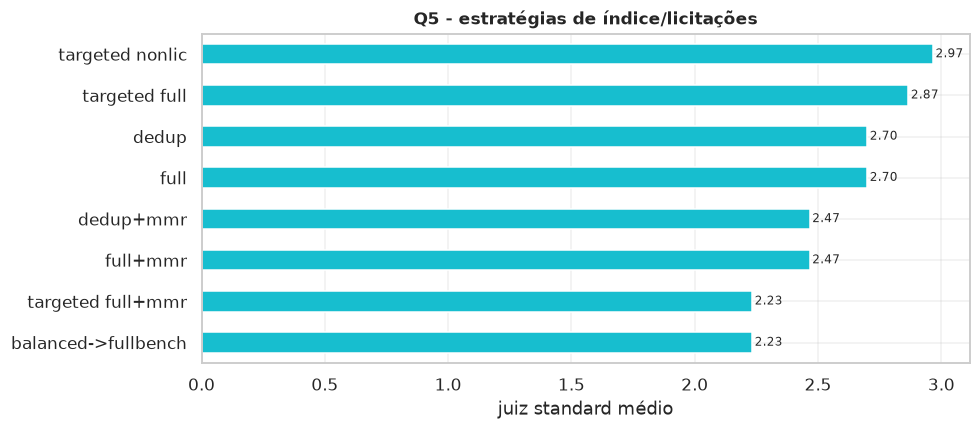

In [19]:
# ablação de estratégias de índice (licitações): média do modo standard por estrategia
strat = {
    "full": "strategy_full.csv", "full+mmr": "strategy_full_mmr.csv",
    "dedup": "strategy_dedup.csv", "dedup+mmr": "strategy_dedup_mmr.csv",
    "balanced->fullbench": "strategy_balanced_on_fullbench.csv",
    "targeted full": "targeted_full.csv", "targeted full+mmr": "targeted_full_mmr.csv",
    "targeted nonlic": "targeted_nonlic_only.csv",
}
vals = {}
for name, f in strat.items():
    r = load_rag_scores(f, modes=("baseline", "standard"))
    if r is not None and "standard" in r.columns:
        vals[name] = r["standard"].dropna().mean()
if not vals: skip("strategy_*.csv / targeted_*.csv")
else:
    s = pd.Series(vals).sort_values()
    ax = s.plot(kind="barh", figsize=(9, 4), color=C["rag"])
    ax.set_xlabel("juiz standard médio"); ax.set_title("Q5 - estratégias de índice/licitações")
    for y, v in enumerate(s.values): ax.text(v + 0.01, y, f"{v:.2f}", va="center", fontsize=8)
    plt.tight_layout(); plt.show()

## 6. Q6 - Guardrails

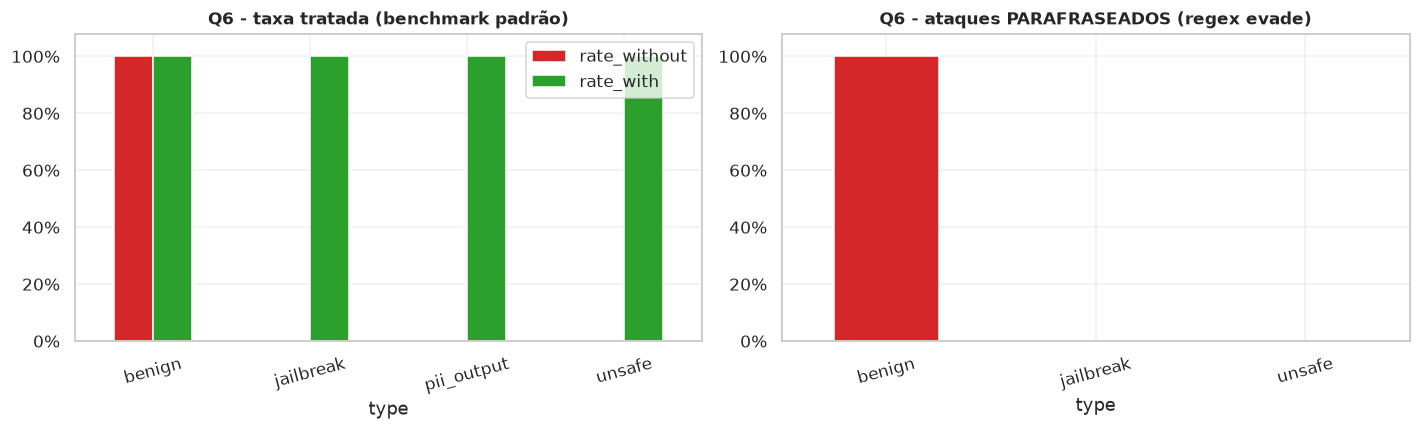

      type  n  handled_with  handled_without  rate_with  rate_without
    benign 15            15               15        1.0           1.0
 jailbreak  5             5                0        1.0           0.0
pii_output  5             5                0        1.0           0.0
    unsafe  5             5                0        1.0           0.0


In [20]:
df = load("q6_guardrails.csv"); adv = load("q6_adversarial.csv")
if df is None: skip("q6_guardrails.csv")
else:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    df.plot(x="type", y=["rate_without", "rate_with"], kind="bar", ax=ax[0],
            color=[C["bad"], C["good"]])
    ax[0].set_title("Q6 - taxa tratada (benchmark padrão)"); ax[0].set_ylim(0, 1.08)
    ax[0].yaxis.set_major_formatter(PercentFormatter(1.0)); ax[0].tick_params(axis="x", rotation=15)
    bar_labels(ax[0], fmt="%.0f%%") if False else None
    if adv is not None:
        adv.plot(x="type", y=["rate_with"], kind="bar", ax=ax[1], color=C["bad"], legend=False)
        ax[1].set_title("Q6 - ataques PARAFRASEADOS (regex evade)"); ax[1].set_ylim(0, 1.08)
        ax[1].yaxis.set_major_formatter(PercentFormatter(1.0)); ax[1].tick_params(axis="x", rotation=15)
    plt.tight_layout(); plt.show(); print(df.to_string(index=False))

## 7. Síntese transversal

Cruzando as questões: escala vs melhor desempenho, e um mapa modelo x questão.

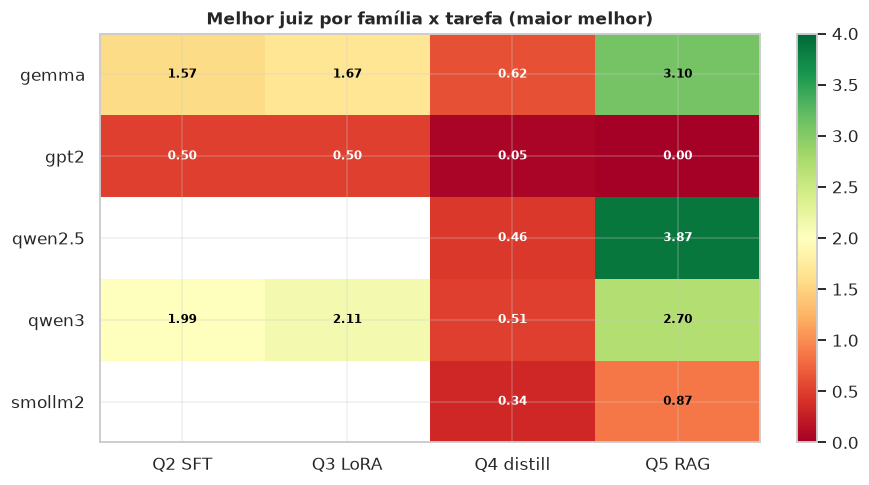

In [21]:
# mapa de calor: melhor juiz alcancado por família/modelo em cada questão (escalas comparaveis: Q2/Q3/Q4 docentes-recall; Q5 RAG)
panel = {}
sft = load("q2_sft.csv"); lora = load("q3_lora.csv"); dist = load("q4_distill.csv"); eng = load("q5_engines.csv")
def fam_of(name):
    n = name.lower()
    if "qwen2.5" in n or "qwen2p5" in n: return "qwen2.5"
    if "qwen3" in n or "qwen" in n: return "qwen3"
    if "gemma" in n: return "gemma"
    if "smollm" in n: return "smollm2"
    if "gpt2" in n: return "gpt2"
    return n
rows = []
if sft is not None:
    d = sft[(sft.eval_set == "recall") & (sft.condition == "sft")]
    for _, r in d.iterrows(): rows.append((fam_of(r["model"]), "Q2 SFT", r["mean_judge"]))
if lora is not None:
    d = lora[lora.eval_set == "recall"]
    for _, r in d.iterrows(): rows.append((fam_of(r["model"]), "Q3 LoRA", r["mean_judge"]))
if dist is not None:
    for _, r in dist.iterrows(): rows.append((fam_of(r["student"]), "Q4 distill", r["distill_judge"]))
if eng is not None:
    d = eng[eng["mode"] == "standard"]
    for _, r in d.iterrows(): rows.append((fam_of(r["engine"]), "Q5 RAG", r["judge"]))
if not rows:
    skip("CSVs de Q2-Q5")
else:
    M = pd.DataFrame(rows, columns=["family", "task", "judge"]).pivot_table(
        index="family", columns="task", values="judge", aggfunc="max")
    M = M.reindex(columns=[c for c in ["Q2 SFT", "Q3 LoRA", "Q4 distill", "Q5 RAG"] if c in M.columns])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    im = ax.imshow(M.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=4)
    ax.set_xticks(range(len(M.columns))); ax.set_xticklabels(M.columns)
    ax.set_yticks(range(len(M.index))); ax.set_yticklabels(M.index)
    annot_heat(ax, M, im)
    ax.set_title("Melhor juiz por família x tarefa (maior melhor)")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()

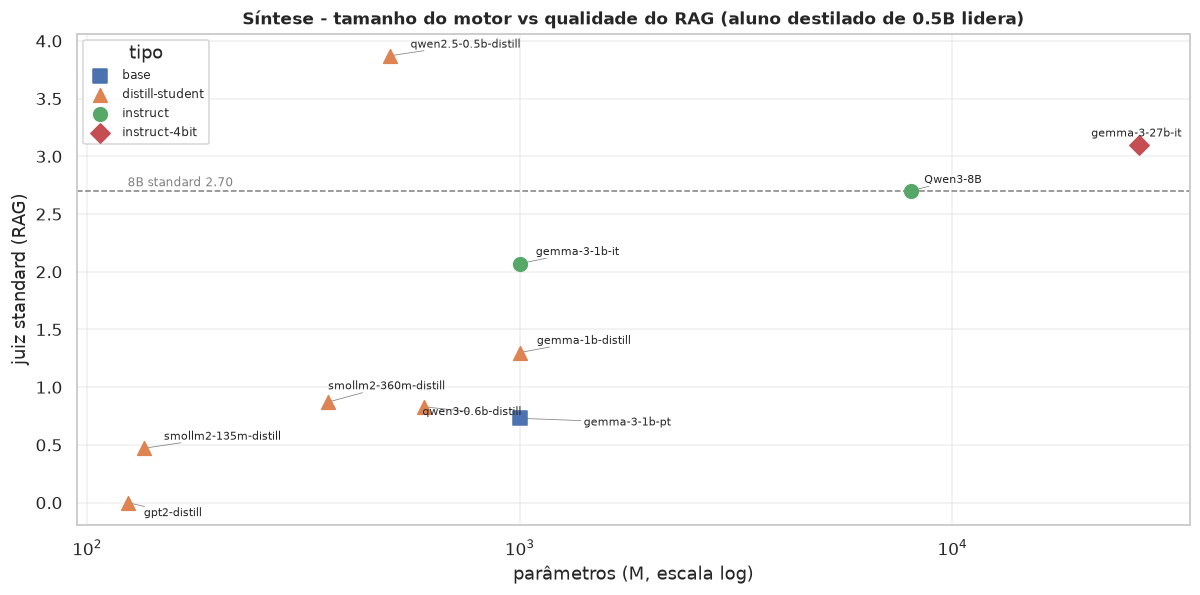

In [22]:
# escala global: parâmetros vs melhor juiz standard de RAG (motores) com rotulos
e = load("q5_engines.csv")
if e is None: skip("q5_engines.csv")
else:
    d = e[e["mode"] == "standard"].copy(); d["m"] = d["params"].map(params_to_m)
    d = d.dropna(subset=["m"]).sort_values("m")
    fig, ax = plt.subplots(figsize=(11, 5.5))
    markers = {"instruct": "o", "base": "s", "distill-student": "^", "instruct-4bit": "D"}
    for kind, grp in d.groupby("kind"):
        ax.scatter(grp["m"], grp["judge"], s=80, marker=markers.get(kind, "o"), label=kind, zorder=3)
    ax.axhline(2.70, ls="--", c="gray", lw=1); ax.text(d["m"].min(), 2.74, "8B standard 2.70", color="gray", fontsize=8)
    ax.set_xscale("log"); ax.set_xlabel("parâmetros (M, escala log)"); ax.set_ylabel("juiz standard (RAG)")
    ax.set_title("Síntese - tamanho do motor vs qualidade do RAG (aluno destilado de 0.5B lidera)")
    ax.legend(fontsize=8, title="tipo")
    texts = [ax.text(r["m"], r["judge"], r["engine"], fontsize=7) for _, r in d.iterrows()]
    if HAS_ADJUST:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
                    expand=(1.4, 1.8))
    plt.tight_layout(); plt.show()